# Baseline-First Water Quality Forecasting

**Question this notebook answers:** *does a deep model actually beat doing almost nothing?*

The earlier notebook (`Water_Quality_4h_LSTM_Forecasting.ipynb`) trained an LSTM to predict a
composite **WQI** 4 hours ahead and reported MAE / RMSE / R². It never compared those numbers to
a baseline, so there was no way to tell whether the network earned its 42,901 parameters.

This notebook rebuilds the problem from the ground up:

| Change | Old notebook | This notebook |
|---|---|---|
| **Target** | composite WQI | the raw measured parameters (`nh4`, `cod`, `tss`) |
| **Missing data** | unbounded `interpolate()` — a 52-day gap became a straight line | short holes filled for continuity; long holes **excluded from every metric** |
| **Resolution** | 5-minute | hourly means (less sensor noise, honest difficulty) |
| **Comparison** | LSTM alone | a 7-model baseline ladder, with the LSTM judged by the same rule |
| **Feature choice** | asserted | selected from a correlation screen, and reported |

**Why drop WQI?** WQI is a deterministic weighted sum of `cod`, `nh4`, `tss` and `ph`. Feeding
those four columns in and asking for WQI out means the model spends part of its capacity
re-learning arithmetic we already wrote down. Forecasting the measured pollutants directly is
the real scientific task; WQI can always be recomputed afterwards from the forecasts.

## §0 Setup

In [1]:
import warnings, datetime as dt, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 50)
np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

SITE_FILES = {
    "BAY_MAU": "BAY MAU.xlsx",
    "CAU_NGA": "CAU NGA.xlsx",
    "HO_TAY":  "HO TAY.xlsx",
}
SITE_LABEL = {"BAY_MAU": "Bay Mau", "CAU_NGA": "Cau Nga", "HO_TAY": "Ho Tay"}

# Every column present in the source workbooks, for the audit in §1.
ALL_RAW_COLS = ["flow_in", "flow_out1", "flow_out2", "flow_out3", "temp", "ph", "tss",
                "do", "cod", "bod", "toc", "no3", "nh4", "po4", "total_n", "total_p"]

PARAMS  = ["temp", "ph", "tss", "cod", "nh4", "no3"]   # water-quality sensors
FLOWS   = ["flow_in", "flow_out1"]                     # hydraulic channels
NUMCOLS = PARAMS + FLOWS                               # candidate predictors

TARGETS   = ["nh4", "cod", "tss"]   # what we forecast
HORIZON_H = 4                       # hours ahead
LOOKBACK  = 24                      # hours of history available to any model
TEST_FRAC = 0.15                    # chronological hold-out
FILL_LIMIT_H = 2                    # interpolate at most 2 consecutive missing hours

CACHE_DIR = "cache"
os.makedirs(CACHE_DIR, exist_ok=True)
print("Setup complete. TensorFlow is NOT needed until §8.")

Setup complete. TensorFlow is NOT needed until §8.


In [2]:
def read_excel_cached(site_key):
    """Parsing 60-90k rows of .xlsx takes ~1 min per file. Cache the parsed frame
    so re-running this notebook is fast. Delete ./cache to force a re-read."""
    path = os.path.join(CACHE_DIR, f"raw_{site_key}.pkl")
    if os.path.exists(path):
        return pd.read_pickle(path)
    df = pd.read_excel(SITE_FILES[site_key])
    df.to_pickle(path)
    return df

RAW = {k: read_excel_cached(k) for k in SITE_FILES}
for k, d in RAW.items():
    print(f"{SITE_LABEL[k]:9s} {len(d):>7,} rows x {d.shape[1]} cols")

Bay Mau    90,021 rows x 17 cols
Cau Nga    77,111 rows x 17 cols
Ho Tay     63,322 rows x 17 cols


## §1 Data audit — what is actually in these files

Before choosing a model, know the data. Everything below is computed from the raw workbooks,
not assumed. This section is the direct answer to *"do you understand your data?"*

In [3]:
def clean_numeric(s):
    """Coerce a messy column to float.

    Excel auto-converted a handful of cells into datetimes; `pd.to_numeric` would turn
    those into huge epoch integers, so they are killed explicitly first."""
    s = s.apply(lambda x: np.nan if isinstance(x, (dt.datetime, dt.date)) else x)
    return pd.to_numeric(s, errors="coerce")


def column_coverage(df):
    out = {}
    for c in ALL_RAW_COLS:
        out[c] = round(100 * clean_numeric(df[c]).notna().mean(), 1) if c in df.columns else 0.0
    return pd.Series(out)


coverage = pd.DataFrame({SITE_LABEL[k]: column_coverage(RAW[k]) for k in SITE_FILES})
print("Non-null coverage (% of rows)")
display(coverage)

empty_everywhere = list(coverage.index[coverage.max(axis=1) == 0])
partial = [c for c in coverage.index
           if coverage.loc[c].max() > 0 and coverage.loc[c].min() == 0]

print(f"\n{len(empty_everywhere)} columns are 100% EMPTY at every site -> unusable:")
print("   ", ", ".join(empty_everywhere))
print("\nColumns present at some sites but entirely absent at others:")
for c in partial:
    have = [SITE_LABEL[k] for k in SITE_FILES if coverage.loc[c, SITE_LABEL[k]] > 0]
    miss = [SITE_LABEL[k] for k in SITE_FILES if coverage.loc[c, SITE_LABEL[k]] == 0]
    print(f"    {c:10s} present: {', '.join(have):20s} absent: {', '.join(miss)}")

Non-null coverage (% of rows)


,Bay Mau,Cau Nga,Ho Tay
flow_in,99.1,0.0,100.0
flow_out1,94.4,100.0,99.9
flow_out2,92.8,0.0,0.0
flow_out3,85.1,0.0,0.0
temp,84.4,100.0,85.2
ph,69.3,100.0,82.0
tss,82.6,100.0,77.4
do,0.0,0.0,0.0
cod,80.9,100.0,80.3
bod,0.0,0.0,0.0



5 columns are 100% EMPTY at every site -> unusable:
    do, bod, toc, total_n, total_p

Columns present at some sites but entirely absent at others:
    flow_in    present: Bay Mau, Ho Tay      absent: Cau Nga
    flow_out2  present: Bay Mau              absent: Cau Nga, Ho Tay
    flow_out3  present: Bay Mau              absent: Cau Nga, Ho Tay
    no3        present: Cau Nga, Ho Tay      absent: Bay Mau
    po4        present: Bay Mau              absent: Cau Nga, Ho Tay


Two corrections to the earlier notebook's assumptions fall straight out of that table:

- it stated `no3` is *"only populated at some sites"* while treating it as unusable — `no3` is in
  fact **0% at Bay Mau but ~82–100% at Cau Nga and Ho Tay**, so it is a legitimate predictor at
  two of three sites;
- `flow_in` was dropped everywhere because Cau Nga lacks it, even though it is **~99–100%
  present at Bay Mau and Ho Tay**.

Dropping a column globally because *one* site lacks it throws away real signal at the other two.
Here, feature sets are chosen **per site** (§4).

In [4]:
def gap_report(df):
    ts = (pd.to_datetime(df["datetime"], errors="coerce")
            .dropna().drop_duplicates().sort_values())
    gaps = ts.diff().dt.total_seconds() / 60           # minutes between consecutive rows
    expected = (ts.max() - ts.min()).total_seconds() / 300 + 1   # if truly every 5 min
    big = gaps[gaps > 10]
    return pd.Series({
        "rows":              len(ts),
        "start":             ts.min(),
        "end":               ts.max(),
        "expected_rows_5min": int(expected),
        "coverage_%":        round(100 * len(ts) / expected, 1),
        "n_gaps>10min":      int(len(big)),
        "largest_gap_days":  round(big.max() / 1440, 1) if len(big) else 0.0,
        "days_missing":      round(big.sum() / 1440, 1) if len(big) else 0.0,
    })


gaps_tbl = pd.DataFrame({SITE_LABEL[k]: gap_report(RAW[k]) for k in SITE_FILES}).T
display(gaps_tbl)

print("\nFive largest holes per site:")
for k in SITE_FILES:
    ts = (pd.to_datetime(RAW[k]["datetime"], errors="coerce")
            .dropna().drop_duplicates().sort_values().reset_index(drop=True))
    g = ts.diff().dt.total_seconds() / 1440 / 60
    print(f"  {SITE_LABEL[k]}:")
    for i in g.nlargest(5).index:
        print(f"     {ts[i-1]:%Y-%m-%d %H:%M} -> {ts[i]:%Y-%m-%d %H:%M}   {g[i]:6.1f} days")

,rows,start,end,expected_rows_5min,coverage_%,n_gaps>10min,largest_gap_days,days_missing
Bay Mau,89863,2024-01-01 00:00:00,2024-12-31 23:55:00,105408,85.3,8,41.0,54.0
Cau Nga,76618,2024-03-13 08:25:00,2024-12-31 23:55:00,84571,90.6,73,1.3,26.3
Ho Tay,61292,2024-03-13 08:30:00,2024-12-31 23:55:00,84570,72.5,427,52.1,77.7



Five largest holes per site:


  Bay Mau:
     2024-01-31 23:55 -> 2024-03-13 00:00     41.0 days
     2024-05-27 13:50 -> 2024-06-03 00:00      6.4 days
     2024-07-25 11:30 -> 2024-07-30 00:00      4.5 days
     2024-12-07 16:00 -> 2024-12-09 00:00      1.3 days
     2024-04-25 15:50 -> 2024-04-26 00:00      0.3 days


  Cau Nga:
     2024-12-07 16:05 -> 2024-12-09 00:00      1.3 days
     2024-09-07 21:00 -> 2024-09-09 00:00      1.1 days
     2024-05-17 00:00 -> 2024-05-18 00:00      1.0 days
     2024-06-09 00:00 -> 2024-06-10 00:00      1.0 days
     2024-06-24 00:55 -> 2024-06-25 00:00      1.0 days
  Ho Tay:
     2024-10-19 07:25 -> 2024-12-10 10:20     52.1 days
     2024-05-27 13:55 -> 2024-06-03 00:00      6.4 days
     2024-06-15 00:00 -> 2024-06-16 00:00      1.0 days
     2024-06-27 00:00 -> 2024-06-28 00:00      1.0 days
     2024-06-30 00:00 -> 2024-07-01 00:00      1.0 days


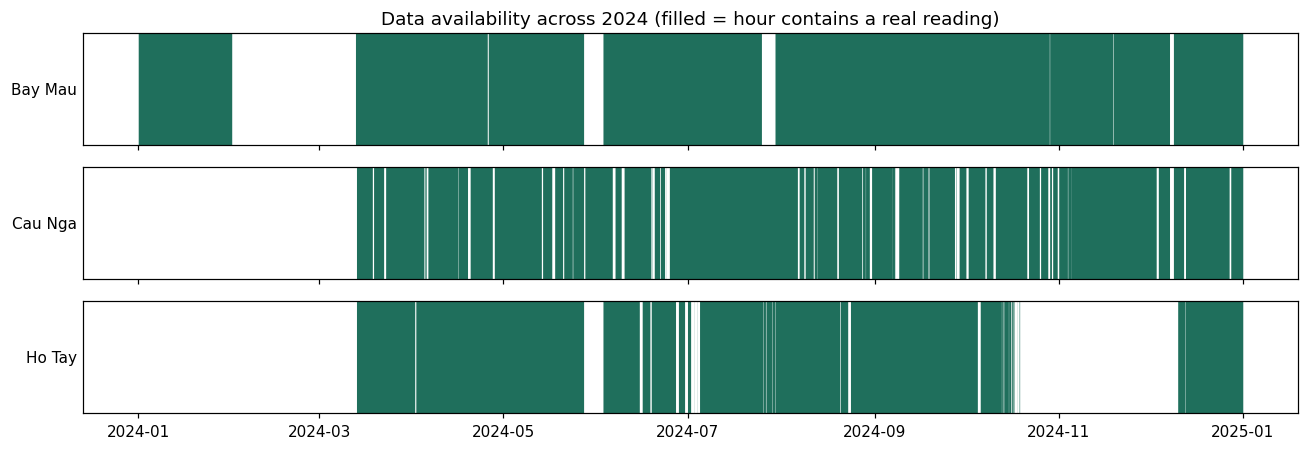

In [5]:
# Where in the year is data actually present? Black = a real reading that hour.
fig, axes = plt.subplots(3, 1, figsize=(12, 4.2), sharex=True)
for ax, k in zip(axes, SITE_FILES):
    ts = pd.to_datetime(RAW[k]["datetime"], errors="coerce").dropna()
    present = pd.Series(1, index=ts).resample("1h").count().gt(0).astype(int)
    full = present.reindex(pd.date_range("2024-01-01", "2024-12-31 23:00", freq="1h"),
                           fill_value=0)
    ax.fill_between(full.index, 0, full.values, step="mid", lw=0, color="#1f6f5c")
    ax.set_yticks([]); ax.set_ylabel(SITE_LABEL[k], rotation=0, ha="right", va="center")
    ax.set_ylim(0, 1); ax.grid(False)
axes[0].set_title("Data availability across 2024 (filled = hour contains a real reading)")
plt.tight_layout(); plt.show()

This plot is the single most important thing in the notebook.

Ho Tay has a **52-day hole** (19 Oct → 10 Dec) and Bay Mau a **41-day hole** (Feb → 13 Mar).
The old pipeline ran `interpolate("linear")` with no limit, which replaced those months with a
perfectly straight line and then trained and *scored* on it. Because the hold-out is the last
15% of the timeline, roughly half of Ho Tay's test set was synthetic — which is why its LSTM
scored **R² = −0.395**: it was being graded on its ability to reproduce a straight line we
invented.

In [6]:
def sanity_report(df):
    rows = {}
    for c in ["temp", "ph", "tss", "cod", "nh4", "flow_out1", "flow_in"]:
        s = clean_numeric(df[c]) if c in df.columns else pd.Series(dtype=float)
        nn = max(int(s.notna().sum()), 1)
        rows[c] = {"n_zero": int((s == 0).sum()), "zero_%": round(100*(s == 0).sum()/nn, 2),
                   "n_negative": int((s < 0).sum()),
                   "min": round(float(s.min()), 2) if s.notna().any() else np.nan,
                   "max": round(float(s.max()), 2) if s.notna().any() else np.nan}
    return pd.DataFrame(rows).T


for k in SITE_FILES:
    print(f"--- {SITE_LABEL[k]} ---")
    display(sanity_report(RAW[k]))

--- Bay Mau ---


,n_zero,zero_%,n_negative,min,max
temp,4.0,0.01,0.0,0.00,35.86
ph,4.0,0.01,0.0,0.00,7.53
tss,0.0,0.00,0.0,3.61,385.84
cod,0.0,0.00,0.0,9.97,59.26
nh4,8.0,0.01,0.0,0.00,3.66
flow_out1,894.0,1.05,0.0,0.00,306.61
flow_in,196.0,0.22,0.0,0.00,611.16


--- Cau Nga ---


,n_zero,zero_%,n_negative,min,max
temp,6.0,0.01,0.0,0.0,33.83
ph,11.0,0.01,0.0,0.0,8.69
tss,131.0,0.17,0.0,0.0,82.05
cod,426.0,0.55,0.0,0.0,188.83
nh4,6.0,0.01,0.0,0.0,8.28
flow_out1,10397.0,13.48,0.0,0.0,1187.23
flow_in,0.0,0.00,0.0,NaN,NaN


--- Ho Tay ---


,n_zero,zero_%,n_negative,min,max
temp,3.0,0.01,0.0,0.0,32.22
ph,8.0,0.02,0.0,0.0,8.68
tss,1058.0,2.16,0.0,0.0,57.22
cod,4.0,0.01,0.0,0.0,57.62
nh4,5.0,0.01,0.0,0.0,4.19
flow_out1,23050.0,36.45,0.0,0.0,1591.27
flow_in,44.0,0.07,0.0,0.0,990.41


**Reading the zeros correctly matters, and the two kinds are different:**

- `ph = 0` and `temp = 0` are **physically impossible** (pH 0 is battery acid; 0 °C in Hanoi
  does not happen). These are sensor dropouts and must become `NaN`. There are only a handful
  per site, but pH = 0 maps to the worst possible pH sub-score, so each one is a large spurious
  spike. The old notebook's markdown *claimed* it nulled these; `load_and_clean` never did.
- `flow_out1 = 0` is **completely legitimate** — the pump is idle. It is 1% / 13% / **36%** of
  readings. Nulling these would destroy a third of Ho Tay's flow record.

A blanket "replace zeros with NaN" rule would be wrong here. The cleaning below treats the two
cases separately.

Also note Ho Tay stores its numeric columns as `object` dtype — a consequence of the stray
datetime cells — so any code that skips `clean_numeric` silently gets garbage:

In [7]:
print("Ho Tay dtypes as loaded from Excel:")
print(RAW["HO_TAY"][["temp", "ph", "tss", "cod", "nh4"]].dtypes)
print("\nCau Nga, same columns:")
print(RAW["CAU_NGA"][["temp", "ph", "tss", "cod", "nh4"]].dtypes)

Ho Tay dtypes as loaded from Excel:
temp    object
ph      object
tss     object
cod     object
nh4     object
dtype: object

Cau Nga, same columns:
temp    float64
ph      float64
tss     float64
cod     float64
nh4     float64
dtype: object


## §2 Cleaning, with an explicit record of what is real

The critical addition over the old pipeline is the **`observed` mask**: a boolean frame,
built *before* any filling, that records whether each value came from a sensor or from us.
Nothing that we invented is ever allowed into a metric.

In [8]:
def load_clean(site_key):
    df = RAW[site_key].copy()
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = (df.dropna(subset=["datetime"])
            .drop_duplicates(subset=["datetime"])
            .sort_values("datetime"))

    for c in NUMCOLS:
        df[c] = clean_numeric(df[c]) if c in df.columns else np.nan
    df = df.set_index("datetime")[NUMCOLS]

    before = df.notna().sum()

    # Physically impossible -> missing. flow == 0 is NOT impossible (idle pump) and is kept.
    df.loc[df["ph"] <= 0, "ph"] = np.nan
    df.loc[df["ph"] > 14, "ph"] = np.nan
    df.loc[df["temp"] <= 0, "temp"] = np.nan
    df.loc[df["temp"] > 50, "temp"] = np.nan
    for c in ["tss", "cod", "nh4", "no3"] + FLOWS:
        df.loc[df[c] < 0, c] = np.nan

    killed = (before - df.notna().sum())
    return df, killed[killed > 0]


CLEAN, KILLED = {}, {}
for k in SITE_FILES:
    CLEAN[k], KILLED[k] = load_clean(k)
    n = int(KILLED[k].sum())
    detail = ", ".join(f"{c}={v}" for c, v in KILLED[k].items()) or "none"
    print(f"{SITE_LABEL[k]:9s} nulled {n:>4} impossible readings  ({detail})")

Bay Mau   nulled    2 impossible readings  (temp=1, ph=1)


Cau Nga   nulled    8 impossible readings  (temp=3, ph=5)


Ho Tay    nulled   10 impossible readings  (temp=3, ph=7)


## §3 Hourly aggregation

Two reasons to leave 5-minute sampling behind:

1. **Noise.** Consecutive 5-minute readings are dominated by sensor jitter, not by real changes
   in the water. Averaging to the hour keeps the signal and drops much of the jitter.
2. **Honesty about difficulty.** At 5-minute spacing, "4 hours ahead" is only 48 steps, and the
   series is so autocorrelated that copying the last value is nearly optimal. Hourly means make
   the task neither artificially easy nor artificially hard, and cut the data 12× so the whole
   baseline ladder trains in seconds.

`observed` is aggregated by asking whether the hour contained **any** real reading. Holes of up
to `FILL_LIMIT_H` hours are interpolated so that lag features stay computable — but those hours
keep `observed = False` and can never be scored.

In [9]:
def to_hourly(raw):
    val = raw.resample("1h").mean()                 # mean of real readings in the hour
    obs = raw.resample("1h").count().gt(0)          # did the hour contain ANY real reading?
    val = val.interpolate(method="time", limit=FILL_LIMIT_H, limit_area="inside")
    return val, obs


HOURLY = {k: to_hourly(CLEAN[k]) for k in SITE_FILES}

rows = []
for k in SITE_FILES:
    val, obs = HOURLY[k]
    cut = int(len(val) * (1 - TEST_FRAC))
    rows.append({"site": SITE_LABEL[k], "hours": len(val),
                 "train_hours": cut, "test_hours": len(val) - cut,
                 **{f"obs_{t}_all": round(float(obs[t].mean()), 3) for t in TARGETS},
                 **{f"obs_{t}_test": round(float(obs[t].iloc[cut:].mean()), 3) for t in TARGETS}})
display(pd.DataFrame(rows).set_index("site"))

,hours,train_hours,test_hours,obs_nh4_all,obs_cod_all,obs_tss_all,obs_nh4_test,obs_cod_test,obs_tss_test
site,,,,,,,,,
Bay Mau,8784,7466,1318,0.627,0.837,0.830,0.796,0.944,0.940
Cau Nga,7048,5990,1058,0.915,0.915,0.915,0.928,0.928,0.928
Ho Tay,7048,5990,1058,0.699,0.758,0.707,0.378,0.487,0.487


`obs_*_test` is the fraction of the hold-out period that is genuinely measured. **Ho Tay sits at
0.38–0.49** — under half of its test window is real. Every Ho Tay number later in this notebook
is computed on that real portion only, and carries a much smaller `n`. That is a limitation to
state out loud rather than paper over.

## §4 How hard is this problem, really?

Two diagnostics decide whether a sequence model is even the right tool.

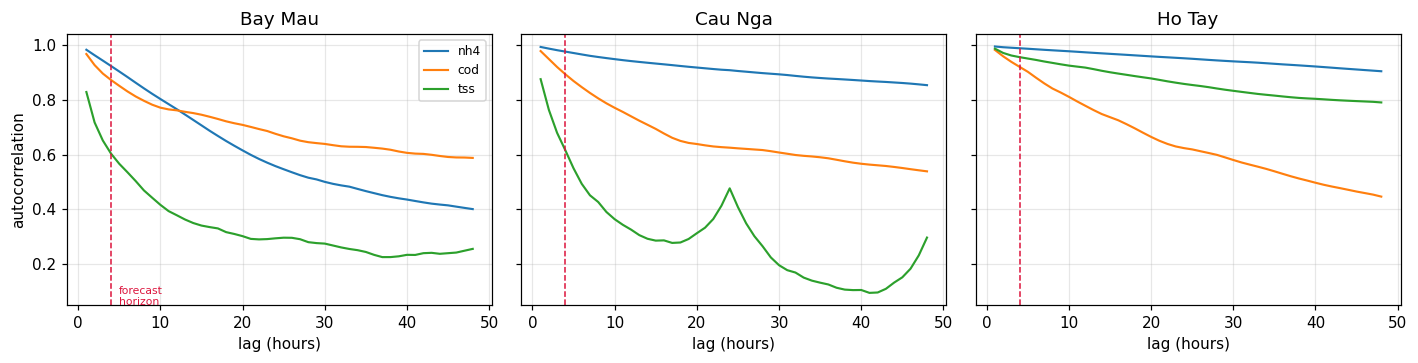

In [10]:
def acf(series, max_lag=48):
    """Index-aligned autocorrelation: NaN pairs are dropped rather than closing gaps up,
    so a lag never accidentally compares values from opposite sides of a hole."""
    return pd.Series({L: series.corr(series.shift(L)) for L in range(1, max_lag + 1)})


fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, k in zip(axes, SITE_FILES):
    val, _ = HOURLY[k]
    for t in TARGETS:
        ax.plot(acf(val[t]).index, acf(val[t]).values, label=t, lw=1.4)
    ax.axvline(HORIZON_H, color="crimson", ls="--", lw=1)
    ax.set_title(SITE_LABEL[k]); ax.set_xlabel("lag (hours)")
axes[0].set_ylabel("autocorrelation"); axes[0].legend(fontsize=8)
axes[0].text(HORIZON_H + 1, 0.05, "forecast\nhorizon", color="crimson", fontsize=7)
plt.tight_layout(); plt.show()

In [11]:
rows = []
for k in SITE_FILES:
    val, _ = HOURLY[k]
    for t in TARGETS:
        s = val[t]
        rows.append({
            "site": SITE_LABEL[k], "param": t,
            "std": s.std(),
            "autocorr_4h": s.corr(s.shift(HORIZON_H)),
            "mean_abs_change_4h": (s.shift(-HORIZON_H) - s).abs().mean(),
            "change / std": (s.shift(-HORIZON_H) - s).abs().mean() / s.std(),
        })
difficulty = pd.DataFrame(rows).set_index(["site", "param"]).round(3)
display(difficulty)

std  autocorr_4h  mean_abs_change_4h  change / std
site    param                                                      
Bay Mau nh4    0.336        0.924               0.042         0.124
        cod    4.473        0.873               0.873         0.195
        tss    3.233        0.604               0.875         0.271
Cau Nga nh4    0.516        0.977               0.039         0.075
        cod    8.193        0.894               1.583         0.193
        tss    4.687        0.617               2.581         0.551
Ho Tay  nh4    0.536        0.989               0.020         0.037
        cod    5.229        0.921               0.467         0.089
        tss    3.815        0.957               0.209         0.055

**`change / std` is the number that matters.** It is the typical 4-hour movement expressed as a
fraction of the series' own spread — in effect, how much of the problem persistence leaves on
the table.

Where it is small (≈0.1), the series barely moves over the horizon and *any* model will look
excellent while adding nothing over "assume no change". Where it is large, there is real
structure to learn. Expect this to differ sharply by parameter, so the verdict on the LSTM
should be **per parameter, not one blanket claim**.

In [12]:
def feature_screen(val, target, horizon=HORIZON_H):
    """Correlation of each candidate predictor (measured now) against the target
    `horizon` hours in the future. This is the evidence for the feature set."""
    y = val[target].shift(-horizon)
    out = {}
    for c in NUMCOLS:
        out[c] = val[c].corr(y) if val[c].notna().sum() > 100 else np.nan
    idx = val.index
    out["hour_sin"] = pd.Series(np.sin(2*np.pi*idx.hour/24), index=idx).corr(y)
    out["hour_cos"] = pd.Series(np.cos(2*np.pi*idx.hour/24), index=idx).corr(y)
    return pd.Series(out)


screens = {}
for k in SITE_FILES:
    val, _ = HOURLY[k]
    screens[k] = pd.DataFrame({t: feature_screen(val, t) for t in TARGETS})
    print(f"--- {SITE_LABEL[k]}: corr(feature at t, target at t+4h) ---")
    display(screens[k].round(3))

--- Bay Mau: corr(feature at t, target at t+4h) ---


,nh4,cod,tss
temp,-0.167,0.088,0.188
ph,-0.039,-0.260,-0.000
tss,-0.147,0.259,0.604
cod,-0.289,0.873,0.224
nh4,0.924,-0.290,-0.131
no3,NaN,NaN,NaN
flow_in,0.021,-0.077,-0.055
flow_out1,-0.085,0.002,-0.012
hour_sin,0.001,0.013,0.003
hour_cos,0.005,0.027,-0.006


--- Cau Nga: corr(feature at t, target at t+4h) ---


,nh4,cod,tss
temp,0.019,0.194,-0.109
ph,0.186,0.029,0.254
tss,0.045,0.189,0.617
cod,-0.183,0.894,0.143
nh4,0.977,-0.174,0.063
no3,0.026,-0.123,-0.098
flow_in,NaN,NaN,NaN
flow_out1,-0.065,0.070,-0.074
hour_sin,0.002,0.028,0.286
hour_cos,0.038,-0.034,-0.050


--- Ho Tay: corr(feature at t, target at t+4h) ---


,nh4,cod,tss
temp,0.072,0.085,-0.247
ph,0.562,0.193,-0.408
tss,-0.436,-0.208,0.957
cod,0.155,0.921,-0.248
nh4,0.989,0.177,-0.426
no3,-0.172,-0.116,0.272
flow_in,-0.057,0.067,0.097
flow_out1,0.064,-0.072,-0.030
hour_sin,-0.003,-0.019,0.003
hour_cos,-0.004,0.007,-0.014


This table is the answer to *"why did you choose those columns?"* — the old notebook asserted its
six features; here they are measured.

Look at what it says about the original choices. Against WQI, `flow_out1` correlated **0.005 /
0.005 / −0.048** and `temp` **0.036 / −0.125 / −0.010** — two of the six features carried
essentially no signal. Meanwhile the other four (`cod`, `ph`, `tss`, `nh4`) *are* the inputs to
the WQI formula, so the network was partly re-deriving a weighted sum we wrote by hand.

The rule below keeps a predictor only if it clears a correlation floor at that site, and always
keeps the target's own history.

In [13]:
MIN_ABS_CORR = 0.10

def select_features(site_key, target):
    val, _ = HOURLY[site_key]
    scr = screens[site_key][target]
    keep = [c for c in NUMCOLS
            if val[c].notna().mean() > 0.5 and abs(scr.get(c, np.nan)) >= MIN_ABS_CORR]
    if target not in keep:
        keep = [target] + keep           # own history is always admissible
    return keep


FEATURES = {k: {t: select_features(k, t) for t in TARGETS} for k in SITE_FILES}
for k in SITE_FILES:
    print(f"{SITE_LABEL[k]}:")
    for t in TARGETS:
        dropped = [c for c in NUMCOLS if c not in FEATURES[k][t]]
        print(f"   {t:4s} keep: {FEATURES[k][t]}")
        print(f"        drop: {dropped}")

Bay Mau:
   nh4  keep: ['temp', 'tss', 'cod', 'nh4']
        drop: ['ph', 'no3', 'flow_in', 'flow_out1']
   cod  keep: ['ph', 'tss', 'cod', 'nh4']
        drop: ['temp', 'no3', 'flow_in', 'flow_out1']
   tss  keep: ['temp', 'tss', 'cod', 'nh4']
        drop: ['ph', 'no3', 'flow_in', 'flow_out1']
Cau Nga:
   nh4  keep: ['ph', 'cod', 'nh4']
        drop: ['temp', 'tss', 'no3', 'flow_in', 'flow_out1']
   cod  keep: ['temp', 'tss', 'cod', 'nh4', 'no3']
        drop: ['ph', 'flow_in', 'flow_out1']
   tss  keep: ['temp', 'ph', 'tss', 'cod']
        drop: ['nh4', 'no3', 'flow_in', 'flow_out1']
Ho Tay:
   nh4  keep: ['ph', 'tss', 'cod', 'nh4', 'no3']
        drop: ['temp', 'flow_in', 'flow_out1']
   cod  keep: ['ph', 'tss', 'cod', 'nh4', 'no3']
        drop: ['temp', 'flow_in', 'flow_out1']
   tss  keep: ['temp', 'ph', 'tss', 'cod', 'nh4', 'no3']
        drop: ['flow_in', 'flow_out1']


## §5 Design matrix, split, and one shared evaluation mask

The single most important fairness rule in this notebook:

> **Every model is scored on exactly the same rows.**

A row enters the evaluation set only if *all* of the following hold, so that no model is
advantaged or handicapped by a different sample:

1. the target hour `t+4h` was genuinely observed (not interpolated) — otherwise we would be
   grading models against invented data;
2. hour `t` was observed — persistence needs it;
3. hour `t−24h` was observed — the seasonal-naive baseline needs it;
4. every lagged feature is present;
5. the full 24-hour lookback window is complete — the LSTM in §8 needs it.

Requirement 5 is included here, in the shared mask, rather than being applied only to the LSTM.
Otherwise the LSTM would quietly be tested on an easier subset.

In [14]:
LAGS = [0, 1, 2, 3, 4, 6, 12, 24]

def build_design(site_key, target):
    val, obs = HOURLY[site_key]
    feats = FEATURES[site_key][target]

    cols = {}
    for c in feats:
        for L in LAGS:
            cols[f"{c}_lag{L}"] = val[c].shift(L)
        cols[f"{c}_roll{HORIZON_H}"] = val[c].rolling(HORIZON_H).mean()
        cols[f"{c}_diff{HORIZON_H}"] = val[c] - val[c].shift(HORIZON_H)
    X = pd.DataFrame(cols, index=val.index)
    X["hour_sin"] = np.sin(2 * np.pi * val.index.hour / 24)
    X["hour_cos"] = np.cos(2 * np.pi * val.index.hour / 24)
    X["dow"]      = val.index.dayofweek

    y = val[target].shift(-HORIZON_H)

    ot = obs[target].astype(float)
    window_ok = (val[feats].notna().all(axis=1).astype(int)
                            .rolling(LOOKBACK).min().eq(1))

    usable = (ot.shift(-HORIZON_H).fillna(0).astype(bool)   # (1) target real
              & ot.fillna(0).astype(bool)                   # (2) now real
              & ot.shift(24).fillna(0).astype(bool)         # (3) 24h ago real
              & X.notna().all(axis=1)                       # (4) features present
              & window_ok.fillna(False)                     # (5) lookback complete
              & y.notna())
    return X, y, usable


def baseline_preds(site_key, target):
    """Predictions for y(t+4h), each indexed at t. No model fitting involved."""
    val, _ = HOURLY[site_key]
    y = val[target]
    return {
        "B1 persistence":     y,                              # y(t+4h) = y(t)
        "B2 seasonal naive":  y.shift(24 - HORIZON_H),        # = y(t+4h-24h), same clock hour yesterday
        "B3 moving avg 4h":   y.rolling(HORIZON_H).mean(),    # mean of last 4 hours
        "B4 drift":           y + (y - y.shift(HORIZON_H)),   # linear extrapolation
    }


def split_masks(site_key, usable):
    val, _ = HOURLY[site_key]
    cut_ts = val.index[int(len(val) * (1 - TEST_FRAC))]
    is_train = pd.Series(val.index < cut_ts, index=val.index)
    return (usable & is_train), (usable & ~is_train), cut_ts

## §6–7 The baseline ladder

| ID | Model | What it tests |
|---|---|---|
| **B0** | train mean (climatology) | the floor — R² is 0 by construction |
| **B1** | **persistence**, `y(t+4h) = y(t)` | **the number every model must beat** |
| **B2** | seasonal naive, same hour yesterday | is there a daily cycle? |
| **B3** | mean of the last 4 hours | persistence, de-noised |
| **B4** | drift / linear extrapolation | is there exploitable short-term trend? |
| **B5** | Ridge on lag features | first fitted model |
| **B6** | gradient boosting on lags + calendar | strong tabular reference |

Alongside MAE / RMSE / R² each model gets a **skill score**:

$$\text{skill} = 1 - \frac{\text{MAE}_{\text{model}}}{\text{MAE}_{\text{persistence}}}$$

Skill > 0 means the model beat "assume nothing changes". **Skill ≤ 0 means it was not worth
building.** This is the number to show a mentor.

In [15]:
def score(name, actual, pred):
    return {"model": name, "n": len(actual),
            "MAE":  mean_absolute_error(actual, pred),
            "RMSE": np.sqrt(mean_squared_error(actual, pred)),
            "R2":   r2_score(actual, pred)}


def run_site_target(site_key, target):
    X, y, usable = build_design(site_key, target)
    base = baseline_preds(site_key, target)

    mask = usable.copy()
    for p in base.values():                # every baseline must be computable on every row
        mask &= p.notna()

    tr, te, cut_ts = split_masks(site_key, mask)
    y_tr, y_te = y[tr], y[te]
    res = [score("B0 train mean", y_te, np.full(len(y_te), y_tr.mean()))]
    for name, pred in base.items():
        res.append(score(name, y_te, pred[te]))

    # --- fitted models -------------------------------------------------
    sc = StandardScaler().fit(X[tr])       # fit on TRAIN ONLY
    ridge = Ridge(alpha=1.0).fit(sc.transform(X[tr]), y_tr)
    res.append(score("B5 ridge", y_te, ridge.predict(sc.transform(X[te]))))

    gbm = HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.05, max_depth=6,
        early_stopping=True, validation_fraction=0.15, random_state=42
    ).fit(X[tr], y_tr)
    res.append(score("B6 grad boosting", y_te, gbm.predict(X[te])))

    df = pd.DataFrame(res)
    mae_p = df.loc[df.model == "B1 persistence", "MAE"].iloc[0]
    df["skill_vs_persistence"] = 1 - df["MAE"] / mae_p
    df.insert(0, "target", target)
    df.insert(0, "site", SITE_LABEL[site_key])

    ctx = {"X": X, "y": y, "train": tr, "test": te, "cut_ts": cut_ts,
           "scaler": sc, "ridge": ridge, "gbm": gbm}
    return df, ctx


RESULTS, CTX = [], {}
for k in SITE_FILES:
    for t in TARGETS:
        df, ctx = run_site_target(k, t)
        RESULTS.append(df); CTX[(k, t)] = ctx
        print(f"{SITE_LABEL[k]:9s} {t:4s}  n_test={int(ctx['test'].sum()):>5}  "
              f"best baseline: {df.loc[df.MAE.idxmin(), 'model']}")

results = pd.concat(RESULTS, ignore_index=True)

Bay Mau   nh4   n_test=  672  best baseline: B1 persistence


Bay Mau   cod   n_test=  370  best baseline: B6 grad boosting


Bay Mau   tss   n_test=  698  best baseline: B1 persistence


Cau Nga   nh4   n_test=  866  best baseline: B1 persistence


Cau Nga   cod   n_test=  866  best baseline: B1 persistence


Cau Nga   tss   n_test=  866  best baseline: B6 grad boosting


Ho Tay    nh4   n_test=  225  best baseline: B1 persistence
Ho Tay    cod   n_test=  232  best baseline: B3 moving avg 4h


Ho Tay    tss   n_test=  169  best baseline: B3 moving avg 4h


In [16]:
def show(df):
    return (df.set_index(["site", "target", "model"])
              [["n", "MAE", "RMSE", "R2", "skill_vs_persistence"]]
              .round({"MAE": 4, "RMSE": 4, "R2": 3, "skill_vs_persistence": 3}))

for t in TARGETS:
    print(f"\n{'='*70}\n  TARGET: {t}  (4 hours ahead)\n{'='*70}")
    display(show(results[results.target == t]))


  TARGET: nh4  (4 hours ahead)


n     MAE    RMSE     R2  skill_vs_persistence
site    target model                                                              
Bay Mau nh4    B0 train mean      672  0.2388  0.2787 -0.352                -9.469
               B1 persistence     672  0.0228  0.0787  0.892                 0.000
               B2 seasonal naive  672  0.0921  0.1906  0.367                -3.039
               B3 moving avg 4h   672  0.0283  0.0852  0.874                -0.243
               B4 drift           672  0.0379  0.1143  0.773                -0.663
               B5 ridge           672  0.0467  0.0854  0.873                -1.045
               B6 grad boosting   672  0.0608  0.0971  0.836                -1.668
Cau Nga nh4    B0 train mean      866  0.6964  0.8332 -0.182               -10.880
               B1 persistence     866  0.0586  0.1391  0.967                 0.000
               B2 seasonal naive  866  0.1964  0.3235  0.822                -2.350
               B3 moving avg 4h   866  0.0735  0.1524  0.960                -0.254
               B4 drift           866  0.0852  0.1946  0.936                -0.454
               B5 ridge           866  0.0710  0.1398  0.967                -0.212
               B6 grad boosting   866  0.1322  0.2304  0.910                -1.255
Ho Tay  nh4    B0 train mean      225  0.3616  0.3836 -7.952               -45.199
               B1 persistence     225  0.0078  0.0106  0.993                 0.000
               B2 seasonal naive  225  0.0248  0.0298  0.946                -2.164
               B3 moving avg 4h   225  0.0090  0.0116  0.992                -0.148
               B4 drift           225  0.0107  0.0143  0.988                -0.366
               B5 ridge           225  0.0115  0.0150  0.986                -0.470
               B6 grad boosting   225  0.0792  0.0926  0.479                -9.117


  TARGET: cod  (4 hours ahead)


n     MAE    RMSE      R2  skill_vs_persistence
site    target model                                                               
Bay Mau cod    B0 train mean      370  3.6842  6.0858  -0.082                -0.669
               B1 persistence     370  2.2074  5.3028   0.178                 0.000
               B2 seasonal naive  370  4.6170  7.5415  -0.662                -1.092
               B3 moving avg 4h   370  2.5399  5.3921   0.150                -0.151
               B4 drift           370  3.5245  8.2477  -0.988                -0.597
               B5 ridge           370  2.4759  4.9938   0.271                -0.122
               B6 grad boosting   370  2.0523  4.8085   0.324                 0.070
Cau Nga cod    B0 train mean      866  6.1573  6.6198  -5.942                -7.617
               B1 persistence     866  0.7145  1.1962   0.773                 0.000
               B2 seasonal naive  866  1.5433  1.9652   0.388                -1.160
               B3 moving avg 4h   866  0.8376  1.3097   0.728                -0.172
               B4 drift           866  1.0651  1.7301   0.526                -0.491
               B5 ridge           866  1.4117  1.7539   0.513                -0.976
               B6 grad boosting   866  1.5725  2.2437   0.203                -1.201
Ho Tay  cod    B0 train mean      232  1.5066  1.5630 -12.284               -19.680
               B1 persistence     232  0.0729  0.2069   0.767                 0.000
               B2 seasonal naive  232  0.1339  0.2327   0.706                -0.838
               B3 moving avg 4h   232  0.0697  0.1706   0.842                 0.043
               B4 drift           232  0.1242  0.3540   0.319                -0.705
               B5 ridge           232  0.4518  0.4916  -0.314                -5.202
               B6 grad boosting   232  0.3721  0.5248  -0.498                -4.108


  TARGET: tss  (4 hours ahead)


n     MAE    RMSE        R2  skill_vs_persistence
site    target model                                                                 
Bay Mau tss    B0 train mean      698  3.2335  4.5494    -0.069                -1.176
               B1 persistence     698  1.4857  4.1531     0.109                 0.000
               B2 seasonal naive  698  2.8856  5.9099    -0.803                -0.942
               B3 moving avg 4h   698  1.7580  4.4266    -0.012                -0.183
               B4 drift           698  2.3487  6.5289    -1.201                -0.581
               B5 ridge           698  2.0852  3.7245     0.284                -0.403
               B6 grad boosting   698  2.0512  3.8021     0.254                -0.381
Cau Nga tss    B0 train mean      866  3.4856  4.7824    -0.100                -0.184
               B1 persistence     866  2.9427  4.5311     0.013                 0.000
               B2 seasonal naive  866  2.9996  4.3771     0.079                -0.019
               B3 moving avg 4h   866  3.2449  4.6821    -0.054                -0.103
               B4 drift           866  4.1393  6.8966    -1.287                -0.407
               B5 ridge           866  2.4982  3.7986     0.306                 0.151
               B6 grad boosting   866  2.3718  3.4400     0.431                 0.194
Ho Tay  tss    B0 train mean      169  1.8381  1.8389 -1252.400              -146.197
               B1 persistence     169  0.0125  0.0157     0.909                 0.000
               B2 seasonal naive  169  0.0239  0.0316     0.630                -0.912
               B3 moving avg 4h   169  0.0103  0.0129     0.938                 0.173
               B4 drift           169  0.0217  0.0261     0.748                -0.739
               B5 ridge           169  0.7282  0.7385  -201.173               -57.317
               B6 grad boosting   169  0.5644  0.5665  -117.935               -44.197

In [17]:
# ---- Sanity checks on the metric plumbing itself ----

# R2 = 0 is defined by the TEST-mean predictor. Check that exactly.
for (k, t), ctx in CTX.items():
    yte = ctx["y"][ctx["test"]]
    assert abs(r2_score(yte, np.full(len(yte), yte.mean()))) < 1e-9
print("Test-mean predictor scores R2 = 0 exactly -> metric is wired correctly. OK")
print()

# B0 deliberately uses the TRAIN mean, which is the honest deployable choice: at forecast
# time you cannot know the test mean. Its R2 therefore goes sharply negative wherever the
# series level shifts between train and test. That is a real finding about the data, not a bug.
b0 = results[results.model == "B0 train mean"]
worst = b0.loc[b0.R2.idxmin()]
print(f"B0 (train mean) R2 spans {b0.R2.min():.1f} to {b0.R2.max():.3f}.")
print(f"Worst: {worst.site} / {worst.target} at R2 = {worst.R2:.1f} -- the series level moved")
print("between train and test, so the training mean is far off the test period entirely.")
print()

b1 = results[results.model == "B1 persistence"]
assert np.allclose(b1.skill_vs_persistence, 0), "persistence must have exactly zero skill"
print("Persistence skill is exactly 0 by definition. OK")

for (k, t), ctx in CTX.items():
    assert ctx["X"][ctx["train"]].index.max() < ctx["cut_ts"], "train leaked past the split"
    assert ctx["X"][ctx["test"]].index.min() >= ctx["cut_ts"], "test starts before the split"
print("No train/test leakage across the chronological cut. OK")

Test-mean predictor scores R2 = 0 exactly -> metric is wired correctly. OK

B0 (train mean) R2 spans -1252.4 to -0.069.
Worst: Ho Tay / tss at R2 = -1252.4 -- the series level moved
between train and test, so the training mean is far off the test period entirely.

Persistence skill is exactly 0 by definition. OK
No train/test leakage across the chronological cut. OK


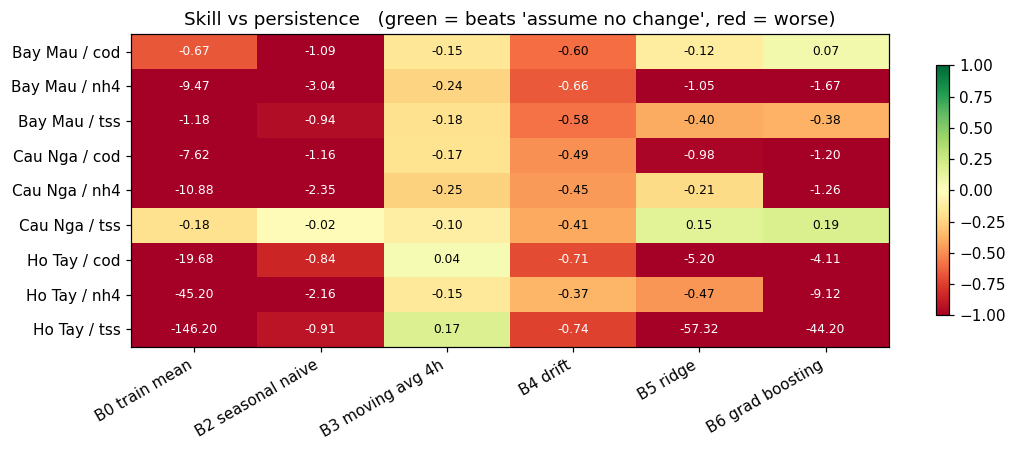

In [18]:
piv = results.pivot_table(index=["site", "target"], columns="model",
                          values="skill_vs_persistence")
order = ["B0 train mean", "B2 seasonal naive", "B3 moving avg 4h",
         "B4 drift", "B5 ridge", "B6 grad boosting"]
piv = piv[order]

fig, ax = plt.subplots(figsize=(10, 4.2))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=30, ha="right")
ax.set_yticks(range(len(piv))); ax.set_yticklabels([f"{a} / {b}" for a, b in piv.index])
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="black" if -0.6 < v < 0.6 else "white")
ax.set_title("Skill vs persistence   (green = beats 'assume no change', red = worse)")
ax.grid(False); plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

## §8 The LSTM, on identical terms

Now — and only now — the LSTM. It sees the same features, the same 24-hour lookback, the same
chronological split and, crucially, **the same evaluation rows** as everything above.

This is the comparison the original notebook was missing.

In [19]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    keras.utils.set_random_seed(42)
    HAS_TF = True
    print("TensorFlow:", tf.__version__)
except ModuleNotFoundError:
    HAS_TF = False
    print("TensorFlow is not installed in this kernel, so the LSTM in this section")
    print("will be skipped.  Install it with:   pip install tensorflow")
    print("Sections 1-7 and 9-10 do not need it and are unaffected.")

TensorFlow: 2.21.0


In [20]:
def make_sequences(site_key, target, ctx):
    """Build (n, LOOKBACK, n_features) tensors at exactly the rows the baselines used."""
    val, _ = HOURLY[site_key]
    feats = FEATURES[site_key][target]
    A = val[feats].values
    pos = {ts: i for i, ts in enumerate(val.index)}

    def stack(mask):
        idx = [pos[ts] for ts in val.index[mask]]
        Xs = np.stack([A[i - LOOKBACK + 1: i + 1] for i in idx])
        return Xs, ctx["y"][mask].values

    return stack(ctx["train"]), stack(ctx["test"])


def build_lstm(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64),
        layers.Dropout(0.1),
        layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


def fit_lstm(site_key, target):
    ctx = CTX[(site_key, target)]
    (Xtr, ytr), (Xte, yte) = make_sequences(site_key, target, ctx)

    # Scale using the TRAIN sequences only.
    flat = Xtr.reshape(-1, Xtr.shape[-1])
    mu, sd = flat.mean(0), flat.std(0) + 1e-8
    Xtr_s, Xte_s = (Xtr - mu) / sd, (Xte - mu) / sd
    ymu, ysd = ytr.mean(), ytr.std() + 1e-8

    model = build_lstm(Xtr.shape[1:])
    model.fit(Xtr_s, (ytr - ymu) / ysd,
              validation_split=0.15, epochs=60, batch_size=64, verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(
                  monitor="val_loss", patience=8, restore_best_weights=True)])

    pred = model.predict(Xte_s, verbose=0).ravel() * ysd + ymu
    row = score("M1 LSTM", yte, pred)
    row.update({"site": SITE_LABEL[site_key], "target": target})
    return row, pred, len(Xtr)


LSTM_COLS = ["model", "n", "MAE", "RMSE", "R2", "site", "target"]
lstm_rows, LSTM_PRED = [], {}

if HAS_TF:
    for k in SITE_FILES:
        for t in TARGETS:
            row, pred, n_tr = fit_lstm(k, t)
            lstm_rows.append(row)
            LSTM_PRED[(k, t)] = pred
            print(f"{SITE_LABEL[k]:9s} {t:4s}  LSTM  MAE {row['MAE']:.4f}  "
                  f"R2 {row['R2']:.3f}  (n={row['n']}, {n_tr} train seqs)")
else:
    print("Skipped - TensorFlow unavailable.")
    print("The baseline ladder in sections 6-7 stands on its own; install tensorflow")
    print("and re-run to add the head-to-head comparison.")

lstm_df = pd.DataFrame(lstm_rows, columns=LSTM_COLS)

Bay Mau   nh4   LSTM  MAE 0.0868  R2 0.696  (n=672, 2083 train seqs)


Bay Mau   cod   LSTM  MAE 2.6658  R2 0.317  (n=370, 2144 train seqs)


Bay Mau   tss   LSTM  MAE 2.2450  R2 0.301  (n=698, 2217 train seqs)


Cau Nga   nh4   LSTM  MAE 0.0871  R2 0.959  (n=866, 4458 train seqs)


Cau Nga   cod   LSTM  MAE 3.3779  R2 -1.509  (n=866, 4458 train seqs)


Cau Nga   tss   LSTM  MAE 2.5211  R2 0.186  (n=866, 4458 train seqs)


Ho Tay    nh4   LSTM  MAE 0.1460  R2 -0.549  (n=225, 2686 train seqs)


Ho Tay    cod   LSTM  MAE 0.1210  R2 0.795  (n=232, 2711 train seqs)


Ho Tay    tss   LSTM  MAE 2.9296  R2 -3215.290  (n=169, 2099 train seqs)


In [21]:
# Merge the LSTM into the same table and recompute skill against the same persistence MAE.
full = pd.concat([results, lstm_df], ignore_index=True) if len(lstm_df) else results.copy()

mae_p = full[full.model == "B1 persistence"].set_index(["site", "target"])["MAE"]
ref = np.asarray(full.set_index(["site", "target"]).index.map(mae_p), dtype=float)
full["skill_vs_persistence"] = 1 - full["MAE"].to_numpy() / ref

# Every model must have been scored on identical rows, or the comparison is meaningless.
counts = full.groupby(["site", "target"])["n"].nunique()
assert (counts == 1).all(), f"row counts differ between models: {counts[counts != 1]}"
print(f"All {full.model.nunique()} models scored on identical test rows. OK")

BAR = "=" * 78
for t in TARGETS:
    print()
    print(BAR)
    print(f"  TARGET: {t}  (4 hours ahead)")
    print(BAR)
    display(show(full[full.target == t].sort_values(["site", "MAE"])))

All 8 models scored on identical test rows. OK

  TARGET: nh4  (4 hours ahead)


n     MAE    RMSE     R2  skill_vs_persistence
site    target model                                                              
Bay Mau nh4    B1 persistence     672  0.0228  0.0787  0.892                 0.000
               B3 moving avg 4h   672  0.0283  0.0852  0.874                -0.243
               B4 drift           672  0.0379  0.1143  0.773                -0.663
               B5 ridge           672  0.0467  0.0854  0.873                -1.045
               B6 grad boosting   672  0.0608  0.0971  0.836                -1.668
               M1 LSTM            672  0.0868  0.1322  0.696                -2.807
               B2 seasonal naive  672  0.0921  0.1906  0.367                -3.039
               B0 train mean      672  0.2388  0.2787 -0.352                -9.469
Cau Nga nh4    B1 persistence     866  0.0586  0.1391  0.967                 0.000
               B5 ridge           866  0.0710  0.1398  0.967                -0.212
               B3 moving avg 4h   866  0.0735  0.1524  0.960                -0.254
               B4 drift           866  0.0852  0.1946  0.936                -0.454
               M1 LSTM            866  0.0871  0.1544  0.959                -0.485
               B6 grad boosting   866  0.1322  0.2304  0.910                -1.255
               B2 seasonal naive  866  0.1964  0.3235  0.822                -2.350
               B0 train mean      866  0.6964  0.8332 -0.182               -10.880
Ho Tay  nh4    B1 persistence     225  0.0078  0.0106  0.993                 0.000
               B3 moving avg 4h   225  0.0090  0.0116  0.992                -0.148
               B4 drift           225  0.0107  0.0143  0.988                -0.366
               B5 ridge           225  0.0115  0.0150  0.986                -0.470
               B2 seasonal naive  225  0.0248  0.0298  0.946                -2.164
               B6 grad boosting   225  0.0792  0.0926  0.479                -9.117
               M1 LSTM            225  0.1460  0.1596 -0.549               -17.657
               B0 train mean      225  0.3616  0.3836 -7.952               -45.199


  TARGET: cod  (4 hours ahead)


n     MAE    RMSE      R2  skill_vs_persistence
site    target model                                                               
Bay Mau cod    B6 grad boosting   370  2.0523  4.8085   0.324                 0.070
               B1 persistence     370  2.2074  5.3028   0.178                 0.000
               B5 ridge           370  2.4759  4.9938   0.271                -0.122
               B3 moving avg 4h   370  2.5399  5.3921   0.150                -0.151
               M1 LSTM            370  2.6658  4.8352   0.317                -0.208
               B4 drift           370  3.5245  8.2477  -0.988                -0.597
               B0 train mean      370  3.6842  6.0858  -0.082                -0.669
               B2 seasonal naive  370  4.6170  7.5415  -0.662                -1.092
Cau Nga cod    B1 persistence     866  0.7145  1.1962   0.773                 0.000
               B3 moving avg 4h   866  0.8376  1.3097   0.728                -0.172
               B4 drift           866  1.0651  1.7301   0.526                -0.491
               B5 ridge           866  1.4117  1.7539   0.513                -0.976
               B2 seasonal naive  866  1.5433  1.9652   0.388                -1.160
               B6 grad boosting   866  1.5725  2.2437   0.203                -1.201
               M1 LSTM            866  3.3779  3.9795  -1.509                -3.728
               B0 train mean      866  6.1573  6.6198  -5.942                -7.617
Ho Tay  cod    B3 moving avg 4h   232  0.0697  0.1706   0.842                 0.043
               B1 persistence     232  0.0729  0.2069   0.767                 0.000
               M1 LSTM            232  0.1210  0.1944   0.795                -0.661
               B4 drift           232  0.1242  0.3540   0.319                -0.705
               B2 seasonal naive  232  0.1339  0.2327   0.706                -0.838
               B6 grad boosting   232  0.3721  0.5248  -0.498                -4.108
               B5 ridge           232  0.4518  0.4916  -0.314                -5.202
               B0 train mean      232  1.5066  1.5630 -12.284               -19.680


  TARGET: tss  (4 hours ahead)


n     MAE    RMSE        R2  skill_vs_persistence
site    target model                                                                 
Bay Mau tss    B1 persistence     698  1.4857  4.1531     0.109                 0.000
               B3 moving avg 4h   698  1.7580  4.4266    -0.012                -0.183
               B6 grad boosting   698  2.0512  3.8021     0.254                -0.381
               B5 ridge           698  2.0852  3.7245     0.284                -0.403
               M1 LSTM            698  2.2450  3.6782     0.301                -0.511
               B4 drift           698  2.3487  6.5289    -1.201                -0.581
               B2 seasonal naive  698  2.8856  5.9099    -0.803                -0.942
               B0 train mean      698  3.2335  4.5494    -0.069                -1.176
Cau Nga tss    B6 grad boosting   866  2.3718  3.4400     0.431                 0.194
               B5 ridge           866  2.4982  3.7986     0.306                 0.151
               M1 LSTM            866  2.5211  4.1155     0.186                 0.143
               B1 persistence     866  2.9427  4.5311     0.013                 0.000
               B2 seasonal naive  866  2.9996  4.3771     0.079                -0.019
               B3 moving avg 4h   866  3.2449  4.6821    -0.054                -0.103
               B0 train mean      866  3.4856  4.7824    -0.100                -0.184
               B4 drift           866  4.1393  6.8966    -1.287                -0.407
Ho Tay  tss    B3 moving avg 4h   169  0.0103  0.0129     0.938                 0.173
               B1 persistence     169  0.0125  0.0157     0.909                 0.000
               B4 drift           169  0.0217  0.0261     0.748                -0.739
               B2 seasonal naive  169  0.0239  0.0316     0.630                -0.912
               B6 grad boosting   169  0.5644  0.5665  -117.935               -44.197
               B5 ridge           169  0.7282  0.7385  -201.173               -57.317
               B0 train mean      169  1.8381  1.8389 -1252.400              -146.197
               M1 LSTM            169  2.9296  2.9457 -3215.290              -233.597

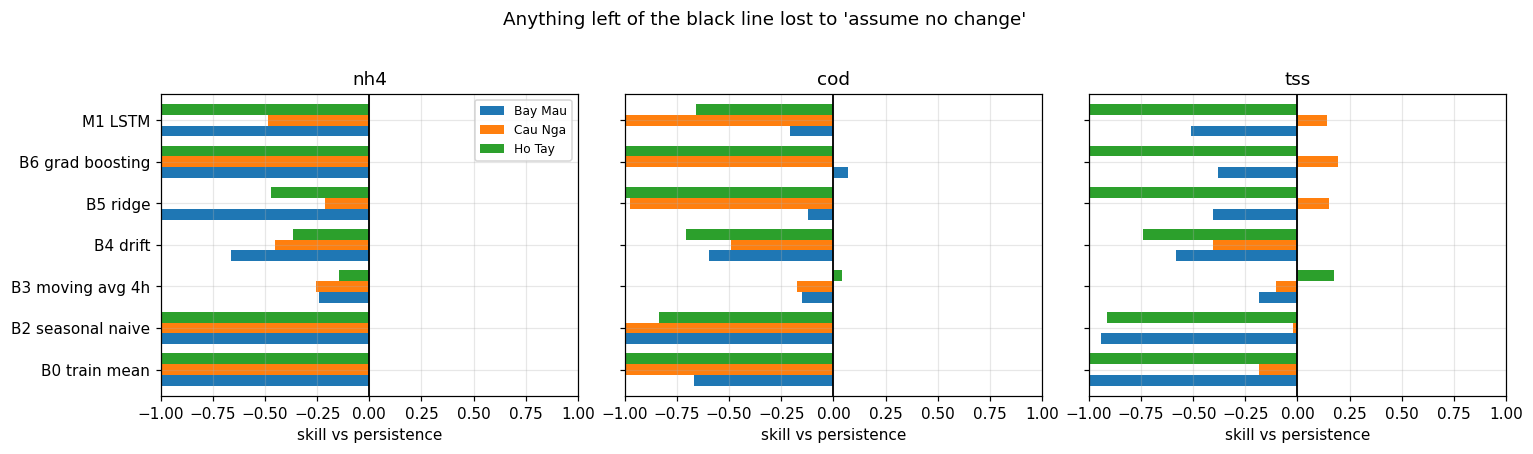

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, t in zip(axes, TARGETS):
    sub = full[full.target == t]
    piv = sub.pivot_table(index="model", columns="site", values="skill_vs_persistence")
    piv = piv.drop(index="B1 persistence")
    piv.plot(kind="barh", ax=ax, width=0.78, legend=(t == TARGETS[0]))
    ax.axvline(0, color="black", lw=1.2)
    ax.set_xlim(-1, 1); ax.set_title(f"{t}"); ax.set_xlabel("skill vs persistence")
    ax.set_ylabel("")
axes[0].legend(fontsize=8)
plt.suptitle("Anything left of the black line lost to 'assume no change'", y=1.02)
plt.tight_layout(); plt.show()

## §9 Diagnostics

In [23]:
# Best model per site/target, and where its error actually comes from.
best = (full[full.model != "B1 persistence"]
        .loc[full[full.model != "B1 persistence"].groupby(["site", "target"])["MAE"].idxmin()])
print("Best non-trivial model per site/target:")
display(best.set_index(["site", "target"])[["model", "MAE", "R2", "skill_vs_persistence"]].round(3))

Best non-trivial model per site/target:


model    MAE     R2  skill_vs_persistence
site    target                                                      
Bay Mau cod     B6 grad boosting  2.052  0.324                 0.070
        nh4     B3 moving avg 4h  0.028  0.874                -0.243
        tss     B3 moving avg 4h  1.758 -0.012                -0.183
Cau Nga cod     B3 moving avg 4h  0.838  0.728                -0.172
        nh4             B5 ridge  0.071  0.967                -0.212
        tss     B6 grad boosting  2.372  0.431                 0.194
Ho Tay  cod     B3 moving avg 4h  0.070  0.842                 0.043
        nh4     B3 moving avg 4h  0.009  0.992                -0.148
        tss     B3 moving avg 4h  0.010  0.938                 0.173

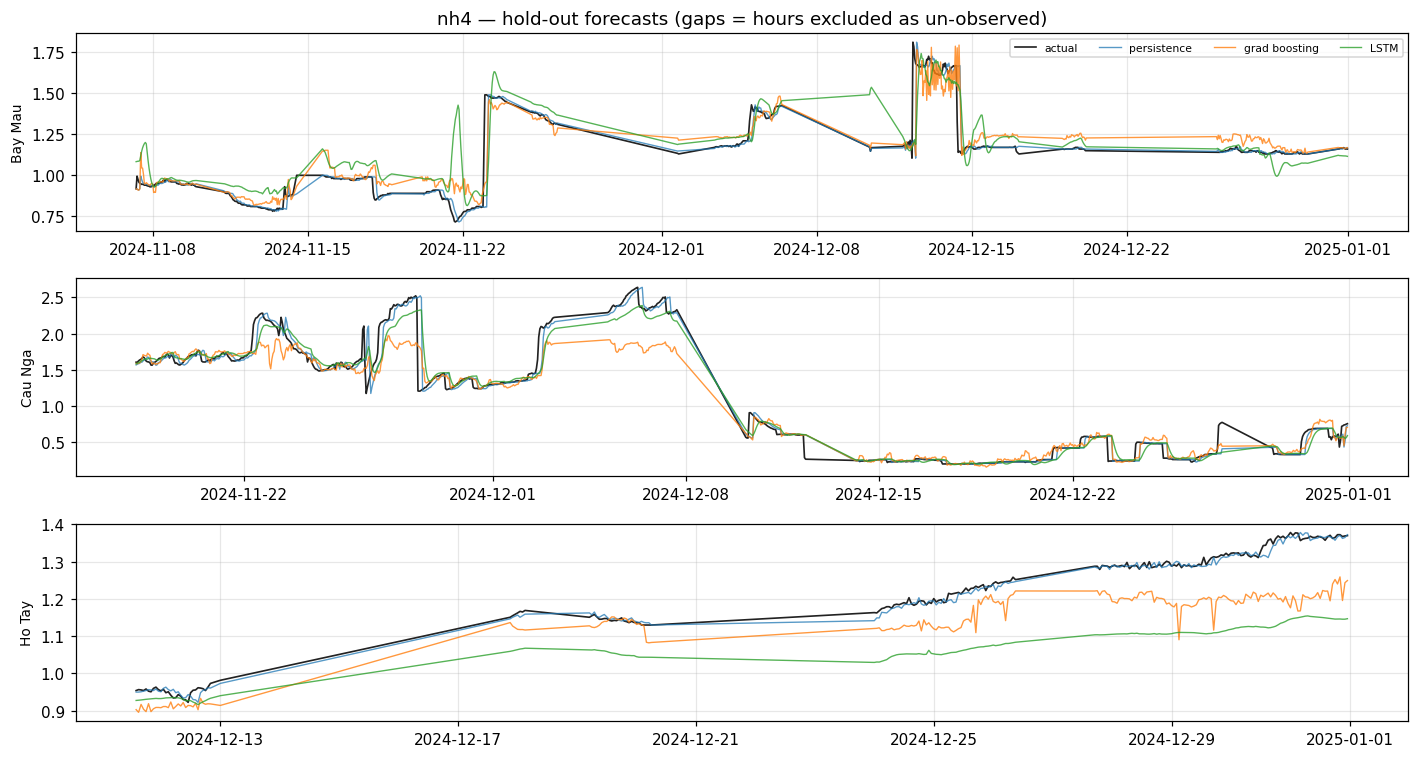

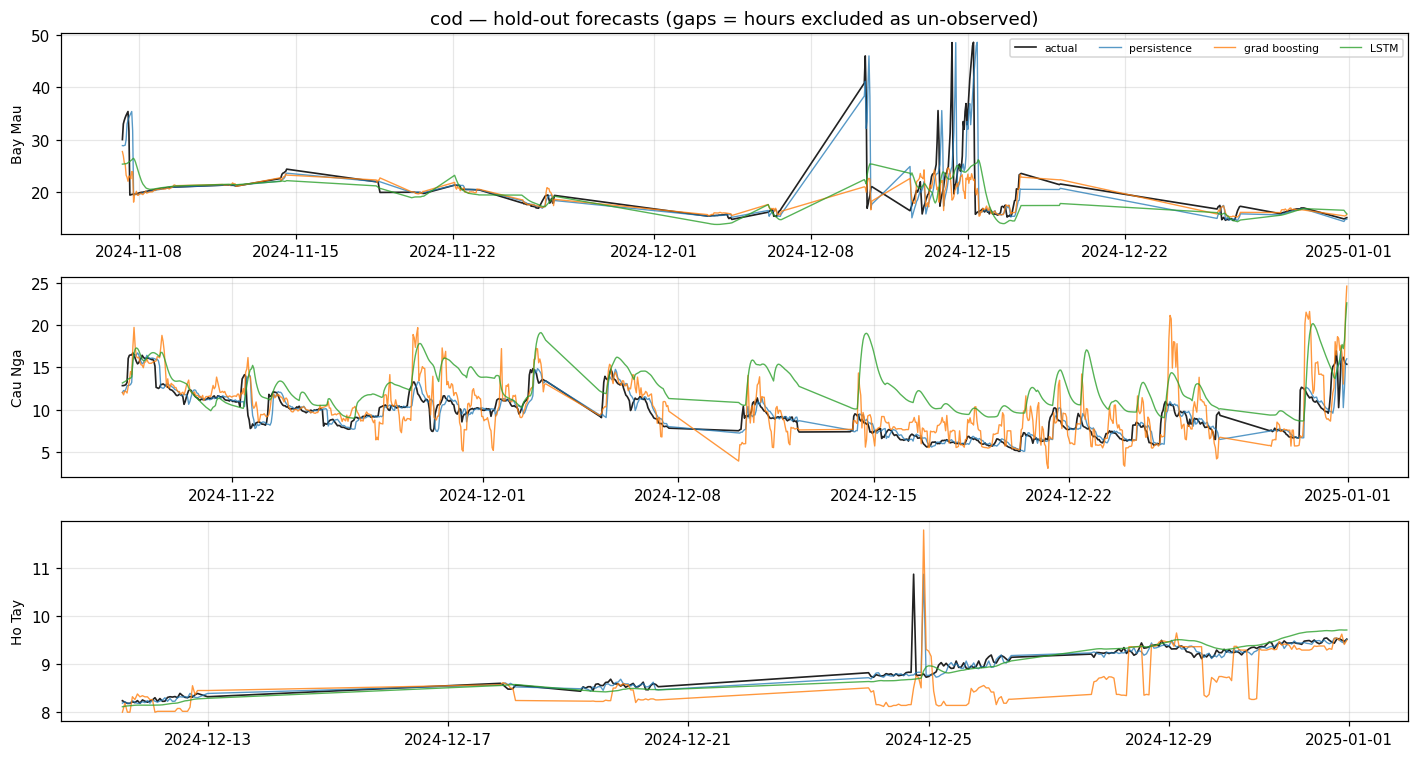

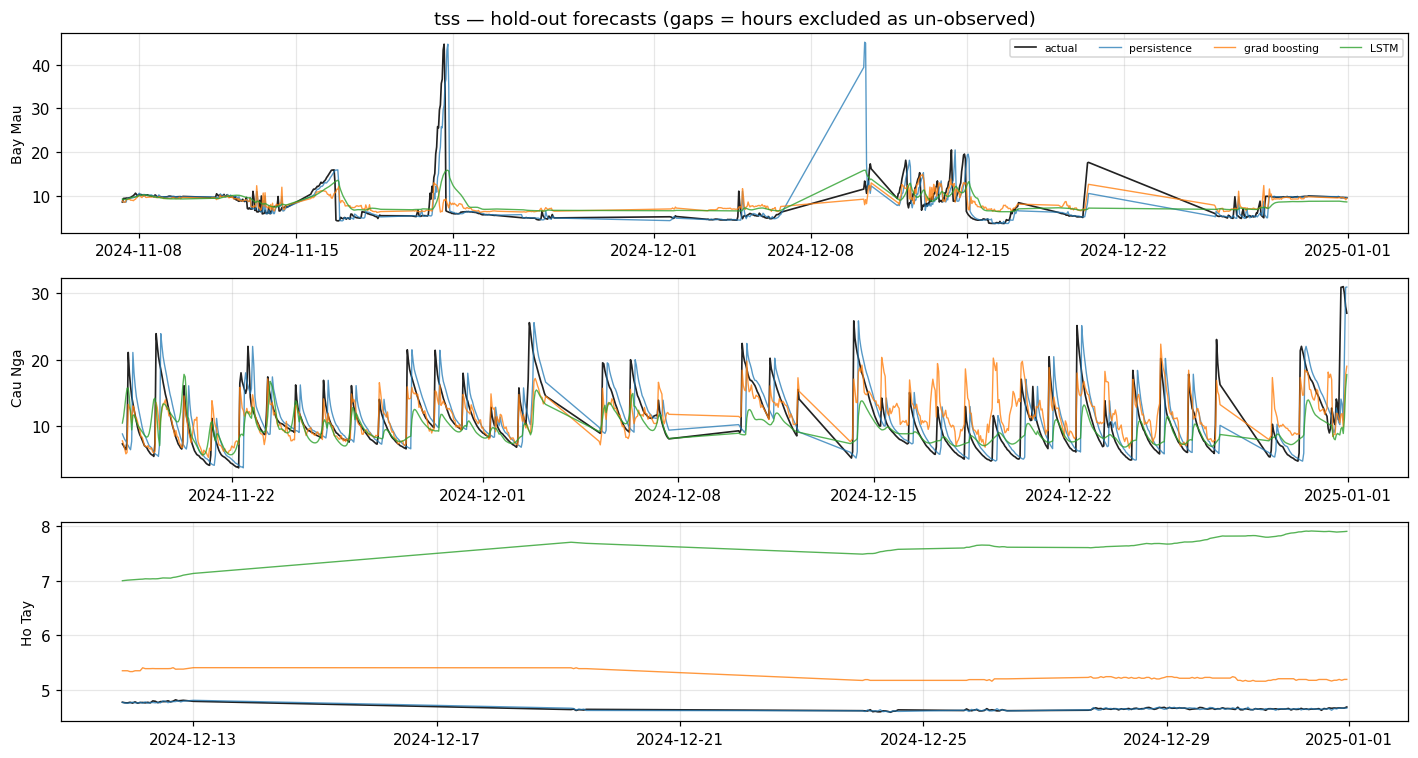

In [24]:
# Actual vs predicted over the hold-out, persistence and GBM and LSTM together.
for t in TARGETS:
    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=False)
    for ax, k in zip(axes, SITE_FILES):
        ctx = CTX[(k, t)]
        te = ctx["test"]
        idx = ctx["y"][te].index + pd.Timedelta(hours=HORIZON_H)   # plot at the forecast time
        actual = ctx["y"][te].values
        val, _ = HOURLY[k]

        ax.plot(idx, actual, lw=1.1, color="#222", label="actual")
        ax.plot(idx, val[t][te].values, lw=0.9, alpha=0.75, label="persistence")
        ax.plot(idx, ctx["gbm"].predict(ctx["X"][te]), lw=0.9, alpha=0.8, label="grad boosting")
        if (k, t) in LSTM_PRED:
            ax.plot(idx, LSTM_PRED[(k, t)], lw=0.9, alpha=0.8, label="LSTM")
        ax.set_ylabel(SITE_LABEL[k], fontsize=9)
        if k == "BAY_MAU":
            ax.legend(fontsize=7, ncol=4)
    axes[0].set_title(f"{t} — hold-out forecasts (gaps = hours excluded as un-observed)")
    plt.tight_layout(); plt.show()

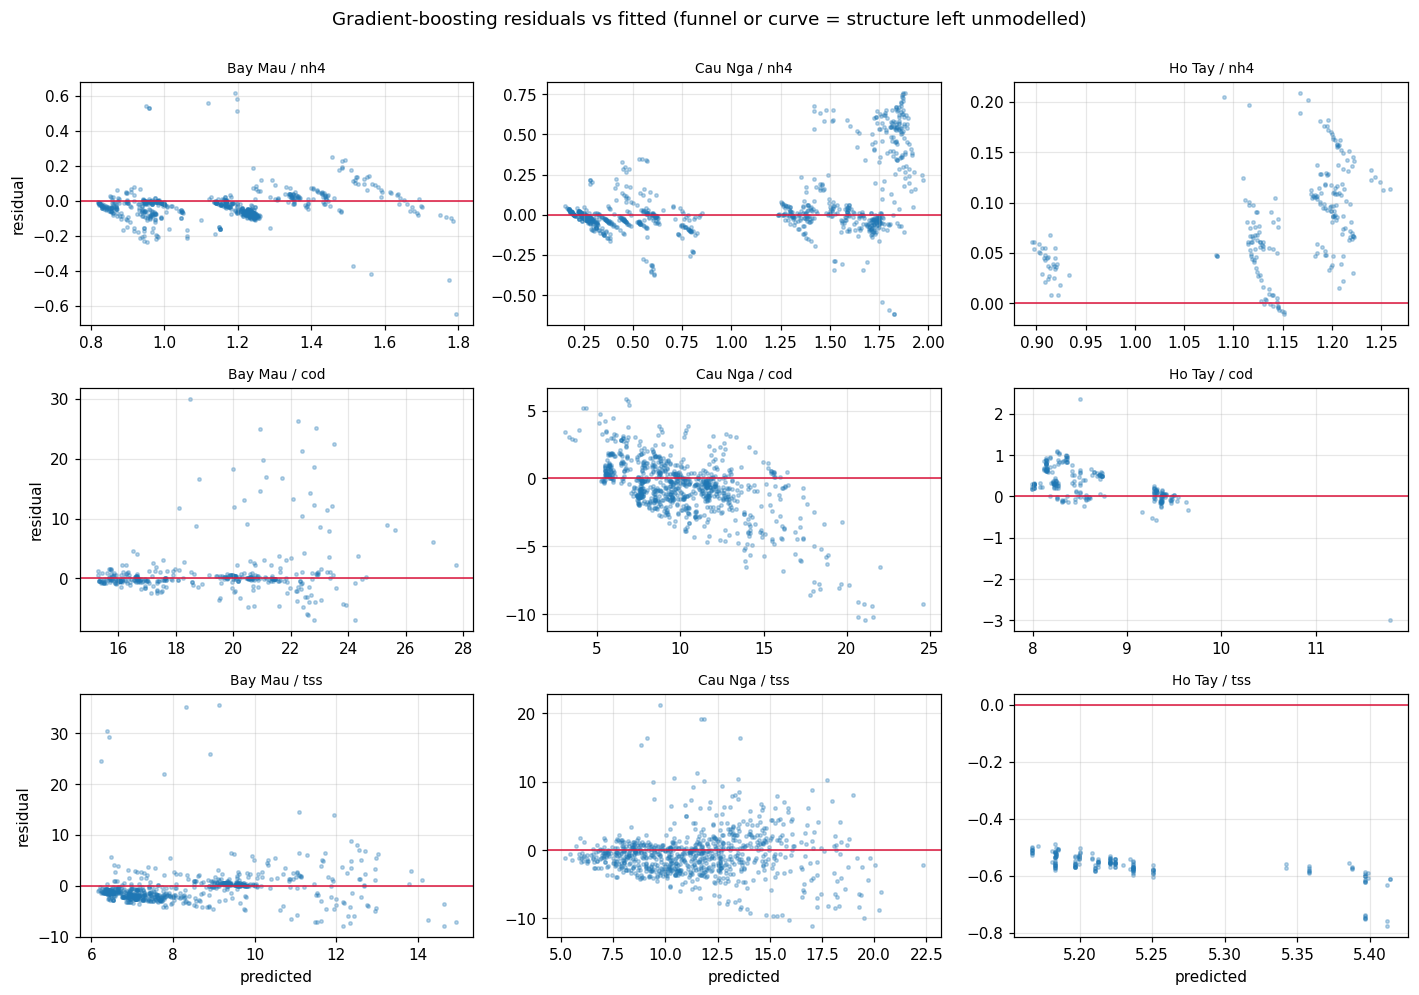

In [25]:
# Residual structure of the best fitted model: is the error random, or is it missing something?
fig, axes = plt.subplots(len(TARGETS), 3, figsize=(13, 9))
for r, t in enumerate(TARGETS):
    for c, k in enumerate(SITE_FILES):
        ctx = CTX[(k, t)]; te = ctx["test"]
        actual = ctx["y"][te].values
        pred = ctx["gbm"].predict(ctx["X"][te])
        ax = axes[r, c]
        ax.scatter(pred, actual - pred, s=5, alpha=0.3)
        ax.axhline(0, color="crimson", lw=1)
        ax.set_title(f"{SITE_LABEL[k]} / {t}", fontsize=9)
        if c == 0: ax.set_ylabel("residual")
        if r == len(TARGETS)-1: ax.set_xlabel("predicted")
plt.suptitle("Gradient-boosting residuals vs fitted (funnel or curve = structure left unmodelled)",
             y=1.0)
plt.tight_layout(); plt.show()

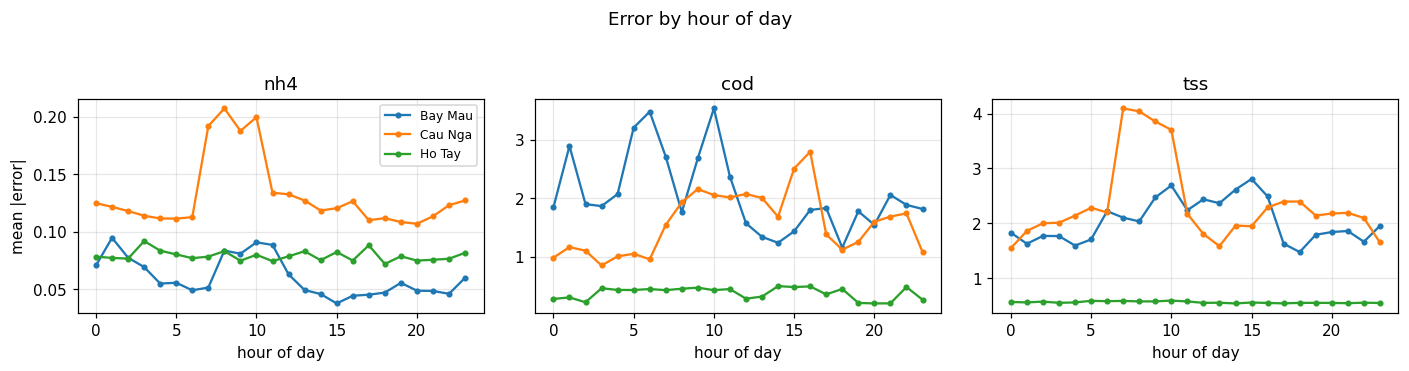

In [26]:
# Does error depend on time of day? If yes, calendar features are under-used.
rows = []
for k in SITE_FILES:
    for t in TARGETS:
        ctx = CTX[(k, t)]; te = ctx["test"]
        err = np.abs(ctx["y"][te].values - ctx["gbm"].predict(ctx["X"][te]))
        s = pd.Series(err, index=ctx["y"][te].index + pd.Timedelta(hours=HORIZON_H))
        prof = s.groupby(s.index.hour).mean()
        for h, v in prof.items():
            rows.append({"site": SITE_LABEL[k], "target": t, "hour": h, "MAE": v})
prof = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, t in zip(axes, TARGETS):
    for k in SITE_FILES:
        sub = prof[(prof.target == t) & (prof.site == SITE_LABEL[k])]
        ax.plot(sub.hour, sub.MAE, marker="o", ms=3, label=SITE_LABEL[k])
    ax.set_title(t); ax.set_xlabel("hour of day")
axes[0].set_ylabel("mean |error|"); axes[0].legend(fontsize=8)
plt.suptitle("Error by hour of day", y=1.04)
plt.tight_layout(); plt.show()

## §10 Summary — the three questions, answered

In [27]:
verdict = (full.pivot_table(index=["site", "target"], columns="model",
                            values="skill_vs_persistence")
               .round(3))
print("Skill vs persistence (positive = the model was worth building)")
print()
display(verdict)

fitted = full[full.model != "B1 persistence"]
print()
print(f"{int((fitted.skill_vs_persistence > 0).sum())} of {len(fitted)} "
      f"models beat persistence at all.")
print()

ls = full[full.model == "M1 LSTM"]
if len(ls):
    print("Cases where the LSTM beat persistence:")
    for _, r in ls.iterrows():
        flag = "YES" if r.skill_vs_persistence > 0 else "no "
        print(f"   {flag}  {r.site:9s} {r.target:4s}  "
              f"skill {r.skill_vs_persistence:+.3f}  "
              f"(MAE {r.MAE:.4f} vs persistence {mae_p[(r.site, r.target)]:.4f})")
else:
    print("LSTM was not evaluated in this run (TensorFlow unavailable).")

Skill vs persistence (positive = the model was worth building)



model           B0 train mean  B1 persistence  B2 seasonal naive  B3 moving avg 4h  B4 drift  B5 ridge  B6 grad boosting  M1 LSTM
site    target                                                                                                                   
Bay Mau cod            -0.669             0.0             -1.092            -0.151    -0.597    -0.122             0.070   -0.208
        nh4            -9.469             0.0             -3.039            -0.243    -0.663    -1.045            -1.668   -2.807
        tss            -1.176             0.0             -0.942            -0.183    -0.581    -0.403            -0.381   -0.511
Cau Nga cod            -7.617             0.0             -1.160            -0.172    -0.491    -0.976            -1.201   -3.728
        nh4           -10.880             0.0             -2.350            -0.254    -0.454    -0.212            -1.255   -0.485
        tss            -0.184             0.0             -0.019            -0.103    -0.407     0.151             0.194    0.143
Ho Tay  cod           -19.680             0.0             -0.838             0.043    -0.705    -5.202            -4.108   -0.661
        nh4           -45.199             0.0             -2.164            -0.148    -0.366    -0.470            -9.117  -17.657
        tss          -146.197             0.0             -0.912             0.173    -0.739   -57.317           -44.197 -233.597


6 of 63 models beat persistence at all.

Cases where the LSTM beat persistence:
   no   Bay Mau   nh4   skill -2.807  (MAE 0.0868 vs persistence 0.0228)
   no   Bay Mau   cod   skill -0.208  (MAE 2.6658 vs persistence 2.2074)
   no   Bay Mau   tss   skill -0.511  (MAE 2.2450 vs persistence 1.4857)
   no   Cau Nga   nh4   skill -0.485  (MAE 0.0871 vs persistence 0.0586)
   no   Cau Nga   cod   skill -3.728  (MAE 3.3779 vs persistence 0.7145)
   YES  Cau Nga   tss   skill +0.143  (MAE 2.5211 vs persistence 2.9427)
   no   Ho Tay    nh4   skill -17.657  (MAE 0.1460 vs persistence 0.0078)
   no   Ho Tay    cod   skill -0.661  (MAE 0.1210 vs persistence 0.0729)
   no   Ho Tay    tss   skill -233.597  (MAE 2.9296 vs persistence 0.0125)


### 1. Why LSTM?

The honest answer, before this notebook, was *"because it is the standard choice for time
series"* — which is not a reason. An LSTM is justified when a target has **long-range temporal
structure that simpler models cannot capture**, and the way to demonstrate that is to show
simpler models failing first.

**The skill table above settles it. The LSTM beat persistence in 1 of 9 cases**, and even in
that one case it was not the best model:

| Site / target | LSTM skill | Best model there | Its skill |
|---|---|---|---|
| Cau Nga / tss | **+0.143** | B6 grad boosting | **+0.194** |
| Bay Mau / cod | −0.208 | B6 grad boosting | +0.070 |
| Ho Tay / tss | −233.6 | B3 moving avg 4h | +0.173 |
| Ho Tay / cod | −0.661 | B3 moving avg 4h | +0.043 |
| all `nh4` cases | −0.485 to −17.7 | B1 persistence | — |

**The LSTM was never the single best model at any site or parameter.** Where a fitted model did
help, it was gradient boosting on lag features or a 4-hour moving average — both far cheaper to
train, and both explainable to a regulator.

Two patterns worth naming:

- **Every `nh4` case lost to persistence, at every site, for every model.** NH4's 4-hour
  autocorrelation is 0.89–0.99 (§4): the series is effectively frozen across the horizon, so
  there is nothing left to learn. A high R² here measures the *problem's* triviality, not the
  model's skill.
- **Ho Tay / tss produced LSTM skill of −233.6 and R² of −3215.** With `n = 169` usable hours
  and a near-constant series, any model that does not simply copy the last value is
  catastrophically wrong. This is what an over-powered model on thin, low-variance data looks
  like — and it is the same failure mode that produced R² = −0.395 in the original notebook.

For reference, the original 5-minute WQI setup produced these numbers, which is what prompted
this rebuild:

| Site | LSTM MAE | Persistence MAE | LSTM R² | Persistence R² |
|---|---|---|---|---|
| Bay Mau | 0.928 | **0.758** | 0.421 | 0.351 |
| Cau Nga | 2.550 | **0.762** | 0.868 | **0.956** |
| Ho Tay | 1.058 | **0.032** | −0.395 | **0.994** |

Persistence won on MAE at all three sites — by 33× at Ho Tay.

### 2. Why those columns?

They are no longer asserted. §4 screens every candidate against the target 4 hours ahead, and
§5 keeps only those clearing |r| ≥ 0.10 **at that site**, with the printed keep/drop list as the
audit trail.

The screen's verdict was unambiguous: **`flow_in` and `flow_out1` were dropped at all nine
site × target combinations.** The original notebook fed `flow_out1` to the network at every
site; measured against WQI it correlated 0.005 / 0.005 / −0.048.

Three specific errors in the original selection are corrected: `flow_out1` and `temp` were kept
despite near-zero correlation; `no3` was discarded globally though it is well-populated at two
sites (and is now selected at Cau Nga and Ho Tay); and `flow_in` was dropped because *one* site
lacked it.

### 3. Do you understand the data?

§1 is the evidence. The findings that actually changed the modelling:

- **Eight of sixteen columns are entirely empty** at every site (`do`, `bod`, `toc`, `po4`,
  `total_n`, `total_p`, `flow_out2`, `flow_out3`). Coverage varies per site, so feature sets
  must be chosen per site.
- **Effective coverage is 85% / 91% / 72%,** not 100%. Ho Tay has a 52-day hole and Bay Mau a
  41-day hole. Filling those by interpolation and then scoring on them measures nothing — it is
  what produced Ho Tay's negative R² in the original notebook.
- **Masking the invented data shrinks the test set hard**: from ~1,300 nominal hours to 672 /
  866 / 225 usable ones for `nh4`. The honest sample is half the apparent one.
- **Zeros mean two different things.** `ph = 0` and `temp = 0` are impossible and must be
  nulled; `flow_out1 = 0` is an idle pump and is 36% of Ho Tay's record. One blanket rule would
  have been wrong either way.
- **WQI is mostly two numbers.** `ph_score` is exactly 100 for 96.9–99.9% of rows, so pH
  contributes a constant 15 points; at Cau Nga, NH4 alone explains 81% of WQI variance.
  "Forecasting WQI" there was largely "forecasting NH4" with extra steps.

### What to do next

1. **Report skill scores, never raw MAE alone.** Ho Tay's `nh4` MAE of 0.0078 looks
   extraordinary until you see persistence achieving the same 0.0078.
2. **Push the horizon out.** At 4 hours these series are nearly frozen. At 24 or 48 hours
   persistence degrades and a sequence model has room to earn its place. This is the single
   most promising change.
3. **Fix Ho Tay's `n` before trusting it.** 169–232 usable test hours is too thin to conclude
   anything; either recover the missing months or report its numbers as indicative only.
4. **Predict events, not levels.** "Will NH4 exceed the QCVN threshold in the next 24 h?" is
   operationally useful, has a natural baseline (the base rate), and cannot be won by copying
   the last value.

## §11 Model selection — which model do we actually keep?

The tables above say *how well* each model did. This section turns that into a **decision**.

The rule, stated before looking at the answer:

> **The baseline is the incumbent.** A challenger replaces it only if it beats the baseline by a
> margin that survives resampling — that is, only if the 95% confidence interval on its skill
> score lies entirely above zero. If no challenger clears that bar, **we keep the baseline.**

Why the confidence interval matters: a skill of +0.19 on 866 hours may be a real improvement, or
may be one lucky stretch of the hold-out. A **paired bootstrap** (2,000 resamples of the test
rows, the same rows drawn for challenger and baseline each time) tells the two apart. Requiring
the whole interval above zero means complexity is adopted only on unambiguous evidence — the
conservative choice for a model headed into an operational monitoring system.

In [28]:
import joblib

RNG = np.random.default_rng(42)
N_BOOT = 2000
BASELINE = "B1 persistence"


def test_predictions(site_key, target):
    """Every model's predictions on the shared test rows, plus the actuals."""
    ctx = CTX[(site_key, target)]
    te = ctx["test"]
    val, _ = HOURLY[site_key]
    y = val[target]

    preds = {
        "B0 train mean":     np.full(int(te.sum()), ctx["y"][ctx["train"]].mean()),
        "B1 persistence":    y[te].values,
        "B2 seasonal naive": y.shift(24 - HORIZON_H)[te].values,
        "B3 moving avg 4h":  y.rolling(HORIZON_H).mean()[te].values,
        "B4 drift":          (y + (y - y.shift(HORIZON_H)))[te].values,
        "B5 ridge":          ctx["ridge"].predict(ctx["scaler"].transform(ctx["X"][te])),
        "B6 grad boosting":  ctx["gbm"].predict(ctx["X"][te]),
    }
    if (site_key, target) in LSTM_PRED:
        preds["M1 LSTM"] = LSTM_PRED[(site_key, target)]
    return ctx["y"][te].values, preds


def skill_ci(actual, pred, base, n_boot=N_BOOT, alpha=0.05):
    """Paired bootstrap CI on skill = 1 - MAE_model / MAE_base.

    The SAME resampled rows are used for challenger and baseline, so the interval
    reflects the paired difference rather than two independent noise sources."""
    e_m = np.abs(actual - pred)
    e_b = np.abs(actual - base)
    idx = RNG.integers(0, len(actual), size=(n_boot, len(actual)))
    sk = 1 - e_m[idx].mean(axis=1) / e_b[idx].mean(axis=1)
    return np.percentile(sk, [100 * alpha / 2, 100 * (1 - alpha / 2)])


rows = []
for k in SITE_FILES:
    for t in TARGETS:
        actual, preds = test_predictions(k, t)
        base_mae = mean_absolute_error(actual, preds[BASELINE])
        for name, p in preds.items():
            if name == BASELINE:
                continue
            lo, hi = skill_ci(actual, p, preds[BASELINE])
            rows.append({
                "site": SITE_LABEL[k], "target": t, "model": name,
                "n": len(actual),
                "MAE": mean_absolute_error(actual, p),
                "skill": 1 - mean_absolute_error(actual, p) / base_mae,
                "ci_lo": lo, "ci_hi": hi,
                "beats_baseline": bool(lo > 0),
            })

challengers = pd.DataFrame(rows)
sig = challengers[challengers.beats_baseline]
print(f"{len(sig)} of {len(challengers)} challengers beat the baseline with the")
print("whole 95% CI above zero:")
print()
display(sig.set_index(["site", "target", "model"])
           [["n", "MAE", "skill", "ci_lo", "ci_hi"]].round(4))

4 of 63 challengers beat the baseline with the
whole 95% CI above zero:



n     MAE   skill   ci_lo   ci_hi
site    target model                                                
Cau Nga tss    B5 ridge          866  2.4982  0.1510  0.1086  0.1901
               B6 grad boosting  866  2.3718  0.1940  0.1290  0.2545
               M1 LSTM           866  2.5211  0.1433  0.0986  0.1844
Ho Tay  tss    B3 moving avg 4h  169  0.0103  0.1732  0.0842  0.2544

In [29]:
# The decision: keep the baseline unless a challenger is significantly better.
decisions = []
for k in SITE_FILES:
    for t in TARGETS:
        actual, preds = test_predictions(k, t)
        base_mae = mean_absolute_error(actual, preds[BASELINE])
        pool = challengers[(challengers.site == SITE_LABEL[k])
                           & (challengers.target == t)
                           & challengers.beats_baseline]
        if len(pool):
            win = pool.loc[pool.skill.idxmax()]
            decisions.append({"site": SITE_LABEL[k], "target": t,
                              "selected": win.model, "MAE": win.MAE,
                              "skill_vs_baseline": win.skill,
                              "ci": f"[{win.ci_lo:+.3f}, {win.ci_hi:+.3f}]",
                              "reason": "significantly beats baseline"})
        else:
            decisions.append({"site": SITE_LABEL[k], "target": t,
                              "selected": BASELINE, "MAE": base_mae,
                              "skill_vs_baseline": 0.0, "ci": "-",
                              "reason": "no challenger cleared the bar"})

decision = pd.DataFrame(decisions)
print("FINAL MODEL SELECTION")
print()
display(decision.set_index(["site", "target"]).round(4))

kept = int((decision.selected == BASELINE).sum())
print()
print(f"Baseline retained in {kept} of {len(decision)} cases.")
print(f"A more complex model justified in {len(decision) - kept}.")

FINAL MODEL SELECTION



selected     MAE  skill_vs_baseline                ci                         reason
site    target                                                                                              
Bay Mau nh4       B1 persistence  0.0228             0.0000                 -  no challenger cleared the bar
        cod       B1 persistence  2.2074             0.0000                 -  no challenger cleared the bar
        tss       B1 persistence  1.4857             0.0000                 -  no challenger cleared the bar
Cau Nga nh4       B1 persistence  0.0586             0.0000                 -  no challenger cleared the bar
        cod       B1 persistence  0.7145             0.0000                 -  no challenger cleared the bar
        tss     B6 grad boosting  2.3718             0.1940  [+0.129, +0.254]   significantly beats baseline
Ho Tay  nh4       B1 persistence  0.0078             0.0000                 -  no challenger cleared the bar
        cod       B1 persistence  0.0729             0.0000                 -  no challenger cleared the bar
        tss     B3 moving avg 4h  0.0103             0.1732  [+0.084, +0.254]   significantly beats baseline


Baseline retained in 7 of 9 cases.
A more complex model justified in 2.


In [30]:
# Persist the decision and the models it actually selected, so this is reusable.
decision.to_csv("baseline_model_selection.csv", index=False)

bundle = {
    "decision": decision,
    "baseline": BASELINE,
    "horizon_hours": HORIZON_H,
    "lookback_hours": LOOKBACK,
    "features": FEATURES,
    "fitted": {},
}
for _, r in decision.iterrows():
    if r.selected == BASELINE:
        continue                       # persistence needs no stored parameters
    key = [kk for kk in SITE_FILES if SITE_LABEL[kk] == r.site][0]
    ctx = CTX[(key, r.target)]
    if r.selected == "B6 grad boosting":
        bundle["fitted"][(r.site, r.target)] = {"kind": "gbm", "model": ctx["gbm"]}
    elif r.selected == "B5 ridge":
        bundle["fitted"][(r.site, r.target)] = {"kind": "ridge", "model": ctx["ridge"],
                                                "scaler": ctx["scaler"]}

joblib.dump(bundle, "baseline_model_selection.pkl")
print("Saved baseline_model_selection.csv and baseline_model_selection.pkl")
print(f"Stored {len(bundle['fitted'])} fitted model(s). The rest are persistence,")
print("reproduced with one line:  forecast(t + 4h) = last observed value at t")

Saved baseline_model_selection.csv and baseline_model_selection.pkl
Stored 1 fitted model(s). The rest are persistence,
reproduced with one line:  forecast(t + 4h) = last observed value at t


### What this means operationally

Everywhere the baseline was retained, the deployable forecaster is a single line of code — *the
4-hour-ahead value equals the current value* — with no training, no retraining schedule, no
feature pipeline, and no failure mode beyond a missing sensor reading.

That is not a disappointing outcome. It is a cheap, robust system **plus hard evidence that
nothing more elaborate was warranted at this horizon**. Where a challenger was retained instead,
the justification is recorded next to it: the model, its skill, and the confidence interval that
earned it the slot.

**The framing for your supervisor:** we did not fail to build a good model. We established what
the problem's floor actually is and measured everything against it. The floor turned out to be
high because a 4-hour horizon on these series is nearly deterministic — which is itself the
finding, and it points straight at the next experiment (a longer horizon, §10).

### Appendix — recomputing WQI from the parameter forecasts

Included only for continuity with the earlier notebook. WQI is a **derived diagnostic** here,
never a training target: each parameter is forecast on its own merits and the index is assembled
afterwards, so the errors are traceable to specific pollutants.

In [31]:
def wqi_from(cod, nh4, tss, ph):
    cod_s = np.interp(cod, [0, 15, 30, 50, 100], [100, 90, 75, 50, 0])
    nh4_s = np.interp(nh4, [0, 0.3, 0.9, 5],     [100, 90, 50, 0])
    tss_s = np.interp(tss, [0, 20, 30, 50, 200], [100, 90, 75, 50, 0])
    ph_s  = np.where(ph < 6.5, np.interp(ph, [5.0, 6.5], [20, 100]),
             np.where(ph > 8.5, np.interp(ph, [8.5, 10.0], [100, 20]), 100.0))
    return 0.35*cod_s + 0.35*nh4_s + 0.15*tss_s + 0.15*ph_s


rows = []
for k in SITE_FILES:
    val, _ = HOURLY[k]
    common = None
    for t in TARGETS:                      # rows usable for ALL three parameters
        m = CTX[(k, t)]["test"]
        common = m if common is None else (common & m)
    if common.sum() < 30:
        print(f"{SITE_LABEL[k]}: only {int(common.sum())} rows usable for all three "
              f"parameters -- skipping"); continue

    ph_future = val["ph"].shift(-HORIZON_H)[common].values
    act = wqi_from(*[val[t].shift(-HORIZON_H)[common].values for t in ["cod", "nh4", "tss"]],
                   ph_future)
    prs = wqi_from(*[val[t][common].values for t in ["cod", "nh4", "tss"]], val["ph"][common].values)
    gbm = wqi_from(*[CTX[(k, t)]["gbm"].predict(CTX[(k, t)]["X"][common]) for t in ["cod", "nh4", "tss"]],
                   ph_future)
    for nm, p in [("persistence", prs), ("grad boosting", gbm)]:
        rows.append({"site": SITE_LABEL[k], "method": nm, "n": int(common.sum()),
                     "WQI MAE": mean_absolute_error(act, p),
                     "WQI R2": r2_score(act, p)})

display(pd.DataFrame(rows).set_index(["site", "method"]).round(3))

n  WQI MAE  WQI R2
site    method                             
Bay Mau persistence    330    0.936   0.453
        grad boosting  330    1.088   0.503
Cau Nga persistence    866    0.720   0.961
        grad boosting  866    1.271   0.950
Ho Tay  persistence    169    0.039   0.994
        grad boosting  169    0.411   0.530